In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [14]:
examples = np.array([[[1,1,1,-1],
                      [-1,1,-1,-1],
                      [-1,1,-1,-1],
                      [-1,1,-1,-1]],
                    [[-1,1,1,1],
                     [-1,-1,1,-1],
                     [-1,-1,1,-1],
                     [-1,-1,1,-1]],
                     [[-1,-1,-1,1],
                      [-1,-1,-1,1],
                      [-1,1,-1,1],
                      [-1,1,1,1]],
                      [[-1,-1,1,-1],
                       [-1,-1,1,-1],
                       [1,-1,1,-1],
                       [1,1,1,-1]]])

y=np.array([1,1,1,-1])


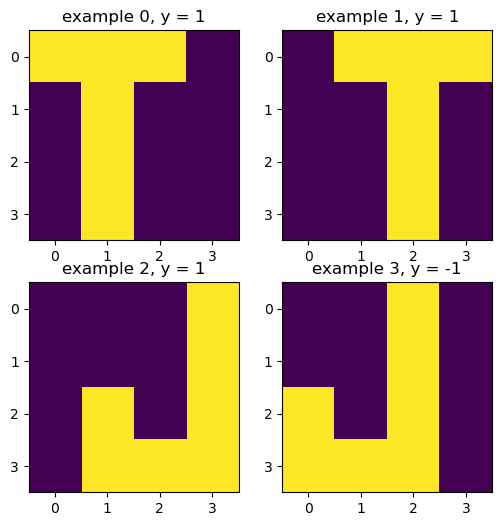

In [15]:
fig= plt.figure(0,(6,6))
for i in range(len(examples)):
    ax = fig.add_subplot(2,2,i+1)
    ax.imshow(examples[i])
    ax.set_title(f"example {i}, y = {y[i]}")


In [16]:

X= examples.reshape(-1,16)   #(4,16)
X=np.hstack((X,np.ones((len(examples),1))))     #(4,17)

print(f"X shape {X.shape}")


X shape (4, 17)


In [17]:
def perceptron_train_with_trace(X, y, lr=1.0, steps=20):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=int)

    d = X.shape[1]
    w = np.zeros(d, dtype=float)
    trace = []

    for t in range(steps):
        i = t % len(y)
        x = X[i]
        yi = y[i]

        score = float(np.dot(x, w))
        pred = 1 if score >= 0 else -1

        w_before = w.copy()
        updated = False
        if yi * score <= 0:
            w = w + lr * yi * x
            updated = True

        trace.append({
            "t": t, "i": i, "x": x.copy(), "y": int(yi),
            "score": score, "pred": int(pred), "updated": updated,
            "w_before": w_before, "w_after": w.copy()
        })

    return w, trace


In [18]:
w_final, trace = perceptron_train_with_trace(X, y, steps=20)
print(len(trace))


20


In [19]:
def show_step(trace, k, grid_shape=(4,4), bias_in_last_col=True):
    if not isinstance(trace, list):
        raise TypeError(f"trace must be a list, got {type(trace)}")

    if len(trace) == 0:
        raise ValueError("trace is empty. You must run training first to fill it.")

    if k < 0 or k >= len(trace):
        raise ValueError(f"k={k} is out of range. trace has len={len(trace)} (valid 0..{len(trace)-1}).")

    r = trace[k]
    x_full = r["x"]
    w_full = r["w_after"]

    if bias_in_last_col:
        x = x_full[:-1]
        w = w_full[:-1]
        bias_w = w_full[-1]
    else:
        x = x_full
        w = w_full
        bias_w = None

    x_img = x.reshape(grid_shape)
    w_img = w.reshape(grid_shape)
    c_img = (x * w).reshape(grid_shape)

    vmax = max(np.max(np.abs(w)), 1e-6)

    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])

    axes[0].imshow(x_img); axes[0].set_title("Input x")
    axes[1].imshow(w_img, vmin=-vmax, vmax=vmax); axes[1].set_title("Weights w")
    axes[2].imshow(c_img, vmin=-vmax, vmax=vmax); axes[2].set_title("Contrib x ⊙ w")

    title = (f"t={r['t']}  example={r['i']}  y={r['y']}  "
             f"score={r['score']:.2f}  pred={r['pred']}  updated={r['updated']}")
    if bias_w is not None:
        title += f"  | bias weight={bias_w:.2f}"

    fig.suptitle(title, fontsize=11)
    plt.show()


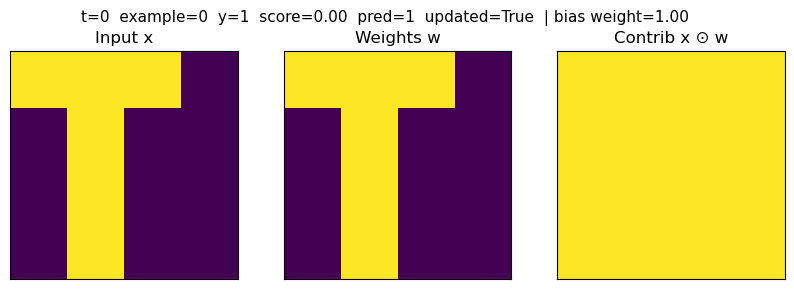

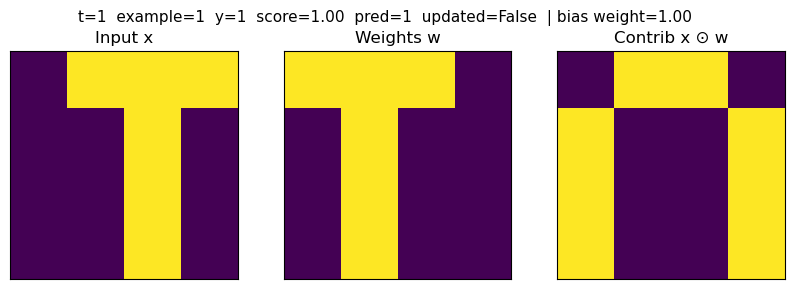

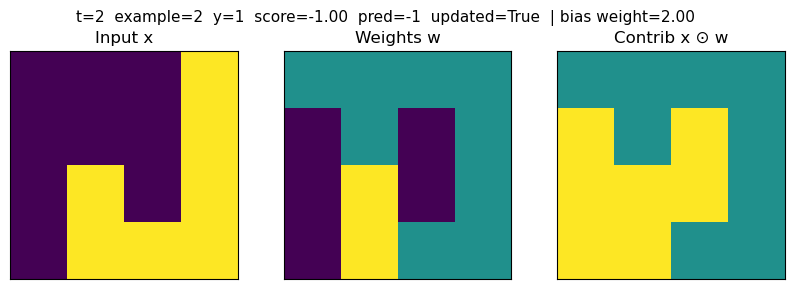

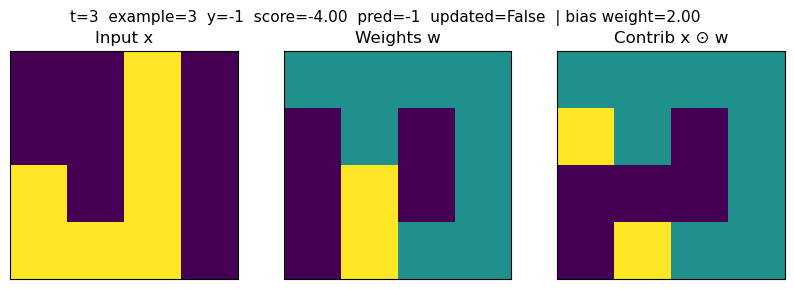

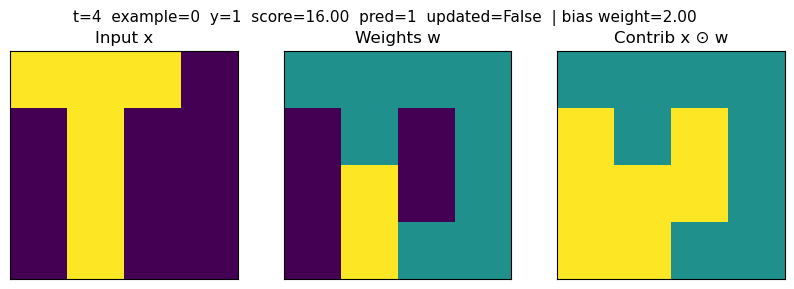

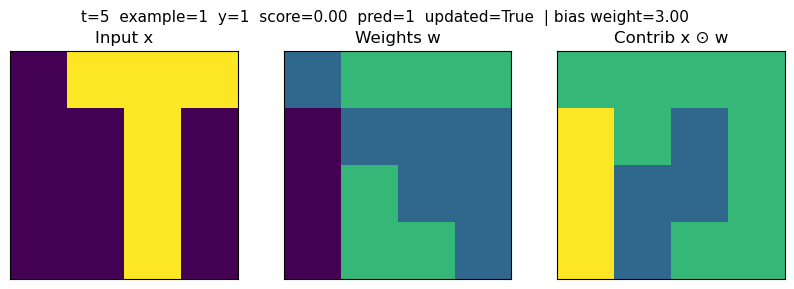

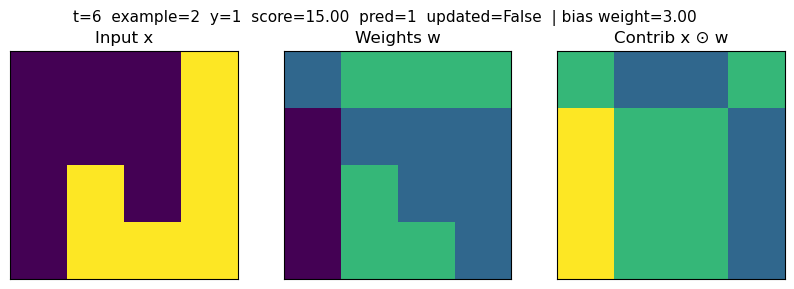

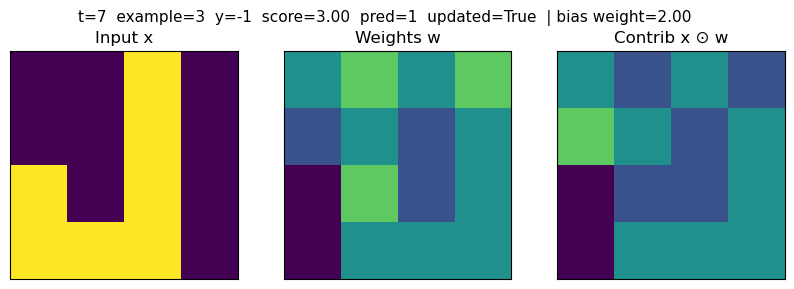

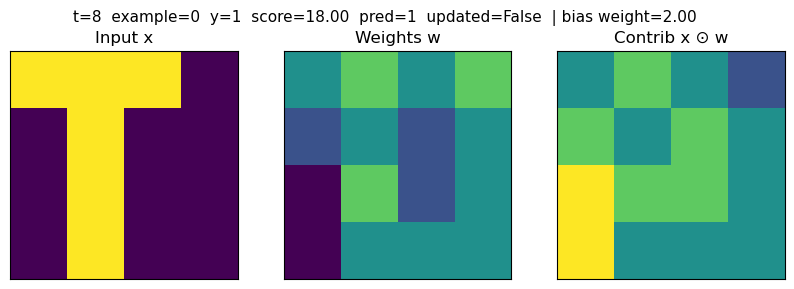

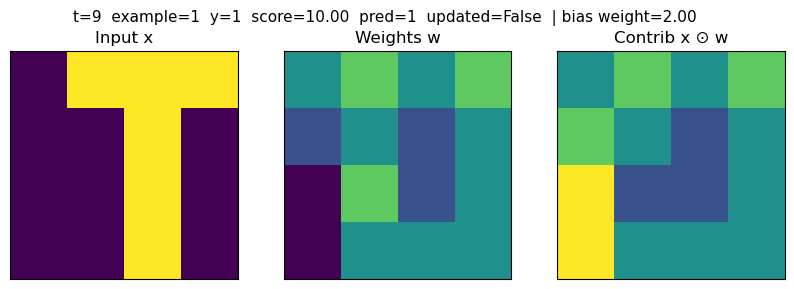

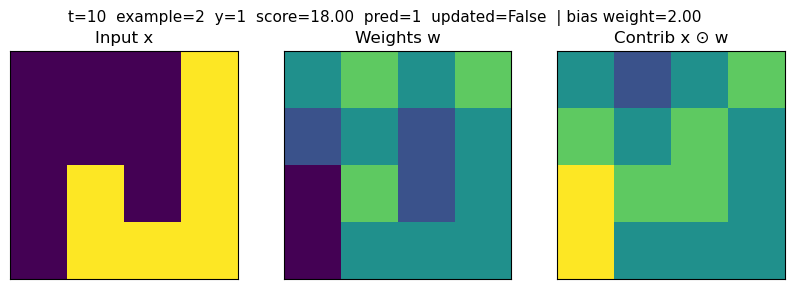

In [20]:
show_step(trace, 0)
show_step(trace, 1)
show_step(trace, 2)
show_step(trace, 3)

show_step(trace, 4)
show_step(trace, 5)
show_step(trace, 6)
show_step(trace, 7)
show_step(trace, 8)
show_step(trace, 9)
show_step(trace, 10)


In [21]:
def animate_training(trace, grid_shape=(4,4), bias_in_last_col=True, interval_ms=700):
    # Compute a global vmax across the run for stable visuals
    W = np.stack([r["w_after"] for r in trace], axis=0)
    W_no_bias = W[:, :-1] if bias_in_last_col else W
    vmax = max(np.max(np.abs(W_no_bias)), 1e-6)

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
    ax_x, ax_w, ax_c = axes
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])

    ax_x.set_title("Input x")
    ax_w.set_title("Weights w")
    ax_c.set_title("Contrib x ⊙ w")

    # init frame
    r0 = trace[0]
    x0 = r0["x"][:-1] if bias_in_last_col else r0["x"]
    w0 = r0["w_after"][:-1] if bias_in_last_col else r0["w_after"]

    im_x = ax_x.imshow(x0.reshape(grid_shape))
    im_w = ax_w.imshow(w0.reshape(grid_shape), vmin=-vmax, vmax=vmax)
    im_c = ax_c.imshow((x0*w0).reshape(grid_shape), vmin=-vmax, vmax=vmax)

    title = fig.suptitle("", fontsize=11)

    def update(frame):
        r = trace[frame]
        x = r["x"][:-1] if bias_in_last_col else r["x"]
        w = r["w_after"][:-1] if bias_in_last_col else r["w_after"]

        im_x.set_data(x.reshape(grid_shape))
        im_w.set_data(w.reshape(grid_shape))
        im_c.set_data((x*w).reshape(grid_shape))

        title.set_text(
            f"t={r['t']} example={r['i']} y={r['y']} score={r['score']:.2f} "
            f"pred={r['pred']} updated={r['updated']}"
        )
        return im_x, im_w, im_c, title

    anim = FuncAnimation(fig, update, frames=len(trace), interval=interval_ms, blit=False)
    return anim


anim = animate_training(trace, interval_ms=700)
anim


In [22]:
def plot_margins_over_time(trace, X, y):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=int)

    W = np.stack([r["w_after"] for r in trace], axis=0)  # (steps, d)
    scores = W @ X.T                                     # (steps, n)
    margins = scores * y[None, :]                        # (steps, n)

    plt.figure(figsize=(9, 4))
    for i in range(X.shape[0]):
        plt.plot(margins[:, i], label=f"example {i} (y={y[i]})")
    plt.axhline(0, linewidth=1)
    plt.title("Margins over time: y*(x·w)  (should go > 0)")
    plt.xlabel("step t")
    plt.ylabel("margin")
    plt.legend()
    plt.show()


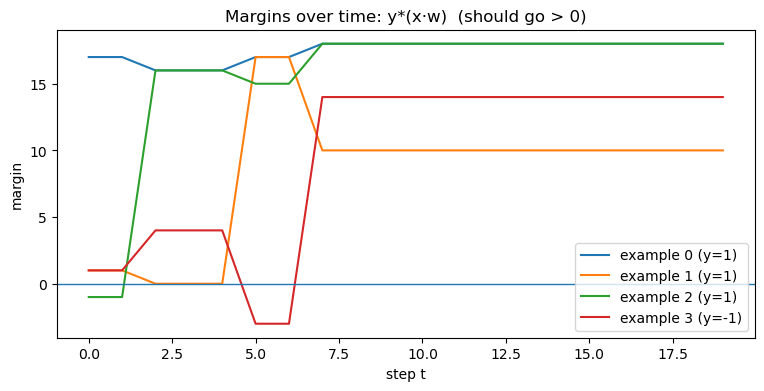

In [23]:
plot_margins_over_time(trace, X, y)
